In [1]:
# 1. Khởi tạo và import thư viện
import os
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, TargetEncoder

# Cấu hình hiển thị và tắt cảnh báo không cần thiết
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100
print("Đã import thành công các thư viện!")

Đã import thành công các thư viện!


In [2]:
# 2. Đọc file dữ diệu
CURRENT_DIR = os.getcwd()
BASE_DIR = os.path.dirname(CURRENT_DIR) if 'notebooks' in CURRENT_DIR else CURRENT_DIR

RAW_DATA_PATH = os.path.join(BASE_DIR, 'data', 'raw', 'DuLieuGiaNhaHCM2024.csv')
MODEL_SAVE_PATH = os.path.join(BASE_DIR, 'models', 'best_model.pkl')

print("Đường dẫn file dữ liệu:", RAW_DATA_PATH)
print("Đường dẫn lưu mô hình:", MODEL_SAVE_PATH)

if not os.path.exists(RAW_DATA_PATH):
    raise FileNotFoundError(f"Không tìm thấy file dữ liệu tại: {RAW_DATA_PATH}")

try:
    df = pd.read_csv(RAW_DATA_PATH, sep='\t', encoding='utf-16')
except Exception:
    try:
        df = pd.read_csv(RAW_DATA_PATH, sep=None, engine='python', encoding='utf-16')
    except Exception:
        df = pd.read_csv(RAW_DATA_PATH, sep=None, engine='python', encoding='utf-8-sig')

print(f"Đã tải dữ liệu thành công! Kích thước: {df.shape[0]} dòng, {df.shape[1]} cột")
display(df.head())

Đường dẫn file dữ liệu: d:\05. CODE\2351050178_HuynhNgocTien\RealEstateTrading\ml\data\raw\DuLieuGiaNhaHCM2024.csv
Đường dẫn lưu mô hình: d:\05. CODE\2351050178_HuynhNgocTien\RealEstateTrading\ml\models\best_model.pkl
Đã tải dữ liệu thành công! Kích thước: 11780 dòng, 10 cột


,Address,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,2.0,2.0,3.0,Have certificate,Full,5.35
1,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,2.0,4.0,4.0,Have certificate,Full,6.90
2,"Đường Phạm Văn Chiêu, Phường 14, Gò Vấp, Hồ Ch...",30.0,NaN,NaN,2.0,2.0,2.0,Have certificate,Full,3.79
3,"Đường Quang Trung, Phường 12, Gò Vấp, Hồ Chí Minh",46.0,4.6,6.0,4.0,4.0,5.0,Have certificate,Full,7.99
4,"Đường Ngô Tất Tố, Phường 22, Bình Thạnh, Hồ Ch...",60.0,3.5,5.0,2.0,6.0,5.0,Have certificate,Full,5.60


In [3]:
# 3.tiền xử lý, lọc outlier theo quận

# Loại bỏ giá trị vô cùng và trùng lặp
df = df.replace([np.inf, -np.inf], np.nan)
before_dup = len(df)
df = df.drop_duplicates()
print(f"Loại trùng lặp: {before_dup} -> {len(df)} dòng")

TARGET_COL = 'Price'

# kiểm tra giá hợp lệ
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors='coerce')
df = df[df[TARGET_COL].notna() & (df[TARGET_COL] > 0)].copy()

# Chuẩn hóa tên cột Bathrooms
if 'Bathroom' in df.columns and 'Bathrooms' not in df.columns:
    df = df.rename(columns={'Bathroom': 'Bathrooms'})

# Hàm tách quận, phường, tên đường
def extract_address_parts(address):
    parts = [p.strip() for p in str(address).strip().split(',')]
    parts = [p for p in parts if p]
    district = parts[-2] if len(parts) >= 2 else (parts[-1] if parts else 'Unknown')
    district = re.sub(r'[.\s]+$', '', district).strip()
    ward = parts[-3] if len(parts) >= 3 else (parts[-2] if len(parts) >= 2 else 'Unknown')
    street = parts[0] if len(parts) >= 1 else 'Unknown'
    return district, ward, street

if 'Address' in df.columns:
    df['District'], df['Ward'], df['Street'] = zip(*df['Address'].apply(extract_address_parts))
    df = df.drop(columns=['Address'])

# Gộp các khu vực hiếm
dist_counts = df['District'].value_counts()
df['District'] = df['District'].replace(dist_counts[dist_counts < 10].index, 'Khác')
ward_counts = df['Ward'].value_counts()
df['Ward'] = df['Ward'].replace(ward_counts[ward_counts < 5].index, 'Khác')

# Tính đơn giá ước tính (trên 1 m2),lọc outlier theo từng quận
df['Price_m2'] = df[TARGET_COL] * 1000 / df['Area']

# Lọc outlier theo từng quận
cleaned_district_dfs = []
for district_name, group in df.groupby('District'):
    q_p_low, q_p_high = group[TARGET_COL].quantile(0.01), group[TARGET_COL].quantile(0.99)
    q_pm2_low, q_pm2_high = group['Price_m2'].quantile(0.02), group['Price_m2'].quantile(0.98)
    q_a_low, q_a_high = group['Area'].quantile(0.01), group['Area'].quantile(0.99)
    
    valid_rows = group[
        (group[TARGET_COL] >= q_p_low) & (group[TARGET_COL] <= q_p_high) &
        (group['Price_m2'] >= q_pm2_low) & (group['Price_m2'] <= q_pm2_high) &
        (group['Area'] >= q_a_low) & (group['Area'] <= q_a_high)
    ]
    cleaned_district_dfs.append(valid_rows)

df = pd.concat(cleaned_district_dfs, ignore_index=True)
df = df.drop(columns=['Price_m2'])
print(f"Sau khi lọc outlier theo Quận: {len(df)} dòng dữ liệu sạch.")

# Điền giá trị thiếu
MEDIAN_COLS = ['Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms']
for col in MEDIAN_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

CAT_COLS = ['Legal status', 'Furniture state']
for col in CAT_COLS:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown').astype(str).str.strip()
        df[col] = df[col].replace({'': 'Unknown'})

Loại trùng lặp: 11780 -> 11771 dòng
Sau khi lọc outlier theo Quận: 11026 dòng dữ liệu sạch.


In [4]:
# 4.Feture engineering(tạo đặc trưng mạnh)

# Tổng số phòng và mật độ phòng trên mỗi tầng
df['Total_Bed_Bath'] = df['Bedrooms'] + df['Bathrooms']
floors_safe = np.where(df['Floors'] < 1, 1, df['Floors'])
df['Rooms_per_Floor'] = df['Total_Bed_Bath'] / floors_safe

# Diện tích bình quân mỗi phòng và Tổng diện tích sàn sử dụng
df['Area_per_Room'] = df['Area'] / (df['Total_Bed_Bath'] + 1)
df['Total_Usable_Area'] = df['Area'] * floors_safe

#Tỷ lệ mặt tiền và đường vào so với diện tích
df['Frontage_Area_Ratio'] = (df['Frontage'] / np.where(df['Area'] == 0, np.nan, df['Area'])).fillna(0)
df['Access_Road_Area_Ratio'] = (df['Access Road'] / np.where(df['Area'] == 0, np.nan, df['Area'])).fillna(0)

# Đặc trưng so sánh tương quan theo khu vực Quận (Tính tự động từ dữ liệu)
district_median_areas = df.groupby('District')['Area'].median().to_dict()
df['Area_to_Dist_Med'] = (df['Area'] / df['District'].map(district_median_areas)).fillna(1.0)

# Tổ hợp vị trí quận + phường
df['Location_Group'] = df['District'] + '_' + df['Ward']

#Biến đổi phi tuyến
df['Area_log'] = np.log1p(df['Area'])
df['Usable_Area_log'] = np.log1p(df['Total_Usable_Area'])
df['Area_sq'] = df['Area'] ** 2

# In kết quả tổng kết
print(f"Tạo đặc trưng thành công! Tổng số features: {df.shape[1] - 1}")
print("\nTrung vị diện tích thực tế theo từng quận:")
for d, med in sorted(district_median_areas.items()):
    print(f"  - {d:15s}: {med:.1f} m²")

Tạo đặc trưng thành công! Tổng số features: 22

Trung vị diện tích thực tế theo từng quận:
  - Bình Chánh     : 85.0 m²
  - Bình Thạnh     : 50.0 m²
  - Bình Tân       : 60.5 m²
  - Củ Chi         : 141.6 m²
  - Gò Vấp         : 60.0 m²
  - Hóc Môn        : 92.0 m²
  - Khác           : 70.5 m²
  - Nhà Bè         : 74.1 m²
  - Phú Nhuận      : 42.0 m²
  - Quận 1         : 35.9 m²
  - Quận 10        : 41.0 m²
  - Quận 11        : 44.0 m²
  - Quận 12        : 66.0 m²
  - Quận 2         : 77.0 m²
  - Quận 3         : 38.0 m²
  - Quận 4         : 40.0 m²
  - Quận 5         : 36.2 m²
  - Quận 6         : 57.0 m²
  - Quận 7         : 64.0 m²
  - Quận 8         : 55.0 m²
  - Quận 9         : 79.0 m²
  - Thủ Đức        : 70.0 m²
  - Tân Bình       : 55.0 m²
  - Tân Phú        : 62.2 m²


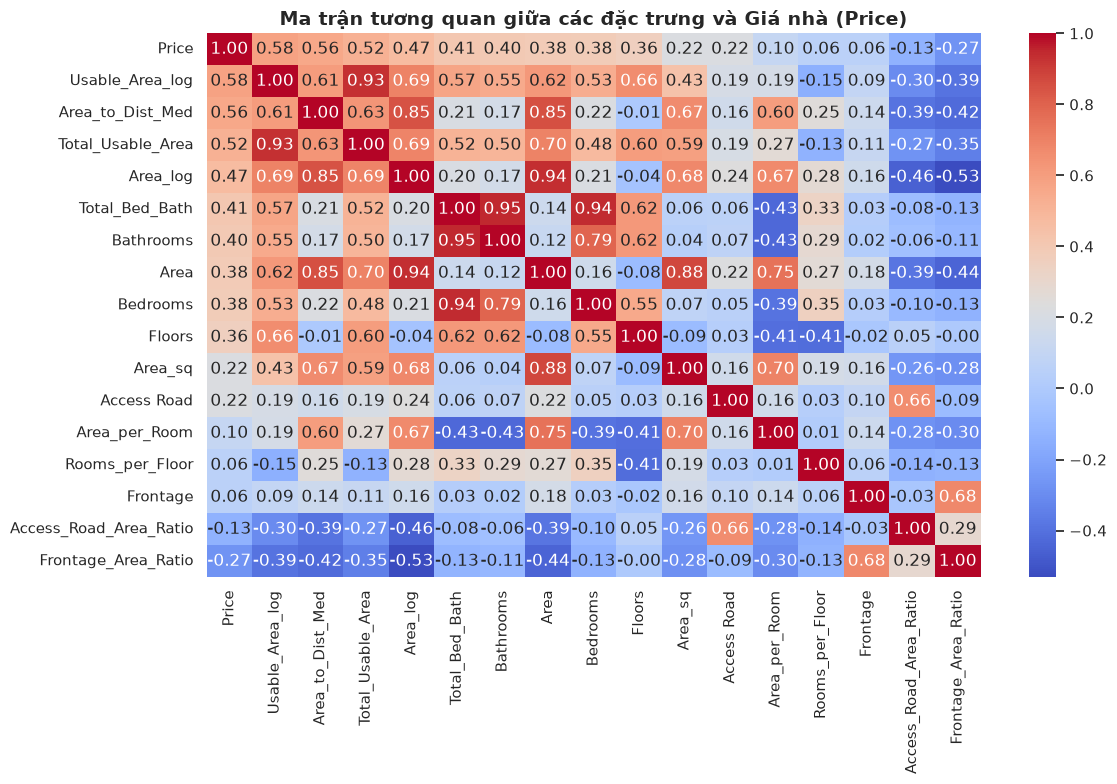

In [5]:
# 5. phân tích ma trận tương quan với giá nhà
plt.figure(figsize=(12, 8))
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_features].corr()

# Lấy top các đặc trưng tương quan mạnh nhất với Price
top_corr_features = corr[TARGET_COL].sort_values(ascending=False).index
sns.heatmap(df[top_corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Ma trận tương quan giữa các đặc trưng và Giá nhà (Price)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# 6. chuẩn bị tập dl và pipeline tiền xử lý

# Danh sách các cột số
NUM_COLS = [
    'Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms',
    'Total_Bed_Bath', 'Rooms_per_Floor', 'Area_per_Room', 'Total_Usable_Area',
    'Frontage_Area_Ratio', 'Access_Road_Area_Ratio', 'Area_to_Dist_Med',
    'Area_log', 'Usable_Area_log', 'Area_sq'
]
NUM_COLS = [c for c in NUM_COLS if c in df.columns]

# Danh sách các cột phân loại
CAT_COLS = ['Legal status', 'Furniture state', 'District', 'Ward', 'Location_Group']
CAT_COLS = [c for c in CAT_COLS if c in df.columns]

X = df[NUM_COLS + CAT_COLS].copy()
# Log-transform biến mục tiêu để ổn định phương sai sai số
y_log = np.log1p(df[TARGET_COL])
y_orig = df[TARGET_COL]

# Chia tập Train và tập Test theo tỷ lệ 80/20
X_train, X_test, y_train_log, y_test_log, y_train_orig, y_test_orig = train_test_split(
    X, y_log, y_orig, test_size=0.2, random_state=42
)

# Preprocessing Pipeline
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', TargetEncoder(smooth=3.0, cv=5))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, NUM_COLS),
    ('cat', cat_transformer, CAT_COLS)
])

print(f"Tập Train: {X_train.shape[0]} mẫu, Tập Test: {X_test.shape[0]} mẫu")

Tập Train: 8820 mẫu, Tập Test: 2206 mẫu


In [7]:
# 7. huấn luyện mô hình

models = {
    'LightGBM': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LGBMRegressor(
            n_estimators=1200, max_depth=8, learning_rate=0.025,
            num_leaves=63, subsample=0.85, colsample_bytree=0.85,
            min_child_samples=15, reg_alpha=0.05, reg_lambda=0.1,
            random_state=42, verbose=-1
        ))
    ]),
    'CatBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('model', CatBoostRegressor(
            iterations=1200, depth=8, learning_rate=0.025,
            l2_leaf_reg=3, random_state=42, verbose=0,
            thread_count=-1, allow_writing_files=False
        ))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(
            n_estimators=1200, max_depth=7, learning_rate=0.025,
            subsample=0.85, colsample_bytree=0.85,
            reg_alpha=0.05, reg_lambda=0.5,
            random_state=42
        ))
    ])
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

print("Đánh giá 5-Fold Cross Validation (R2 trên thang đo log)")
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train_log, cv=kf, scoring='r2', n_jobs=-1)
    cv_results.append({'Model': name, 'CV R2 Mean': scores.mean(), 'CV R2 Std': scores.std()})
    print(f"{name:15s}: CV R2 = {scores.mean():.4f} (+/- {scores.std():.4f})")

cv_df = pd.DataFrame(cv_results).sort_values(by='CV R2 Mean', ascending=False)
display(cv_df)

Đánh giá 5-Fold Cross Validation (R2 trên thang đo log)
LightGBM       : CV R2 = 0.7401 (+/- 0.0042)
CatBoost       : CV R2 = 0.7424 (+/- 0.0031)
XGBoost        : CV R2 = 0.7400 (+/- 0.0030)


,Model,CV R2 Mean,CV R2 Std
1,CatBoost,0.742416,0.003082
0,LightGBM,0.740117,0.004230
2,XGBoost,0.740048,0.002975


In [8]:
# 8. huấn luyện và test trên tập test 

test_eval_results = []
fitted_models = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train_log)
    fitted_models[name] = pipe
    
    pred_log = pipe.predict(X_test)
    pred_orig = np.expm1(pred_log)  # Chuyển về đơn vị tỷ VNĐ ban đầu
    
    r2_orig = r2_score(y_test_orig, pred_orig)
    r2_log = r2_score(y_test_log, pred_log)
    mae = mean_absolute_error(y_test_orig, pred_orig)
    rmse = np.sqrt(mean_squared_error(y_test_orig, pred_orig))
    
    test_eval_results.append({
        'Mô hình': name,
        'R2 (Thực tế)': r2_orig,
        'R2 (Log)': r2_log,
        'MAE (tỷ VNĐ)': mae,
        'RMSE (tỷ VNĐ)': rmse
    })

eval_df = pd.DataFrame(test_eval_results).sort_values(by='R2 (Thực tế)', ascending=False)
print("\nBẢNG ĐÁNH GIÁ HIỆU SUẤT TRÊN TẬP TEST")
display(eval_df)

# Chọn mô hình có R2 thực tế cao nhất
best_model_name = eval_df.iloc[0]['Mô hình']
best_model = fitted_models[best_model_name]
best_r2 = eval_df.iloc[0]['R2 (Thực tế)']
best_mae = eval_df.iloc[0]['MAE (tỷ VNĐ)']
best_rmse = eval_df.iloc[0]['RMSE (tỷ VNĐ)']

print(f"\n Mô hình tốt nhất: {best_model_name} với R2 = {best_r2:.4f} (~{best_r2*100:.1f}%)")


BẢNG ĐÁNH GIÁ HIỆU SUẤT TRÊN TẬP TEST


,Mô hình,R2 (Thực tế),R2 (Log),MAE (tỷ VNĐ),RMSE (tỷ VNĐ)
2,XGBoost,0.719388,0.752620,0.797036,1.072754
0,LightGBM,0.718271,0.752699,0.808854,1.074887
1,CatBoost,0.711502,0.750331,0.822325,1.087724



 Mô hình tốt nhất: XGBoost với R2 = 0.7194 (~71.9%)


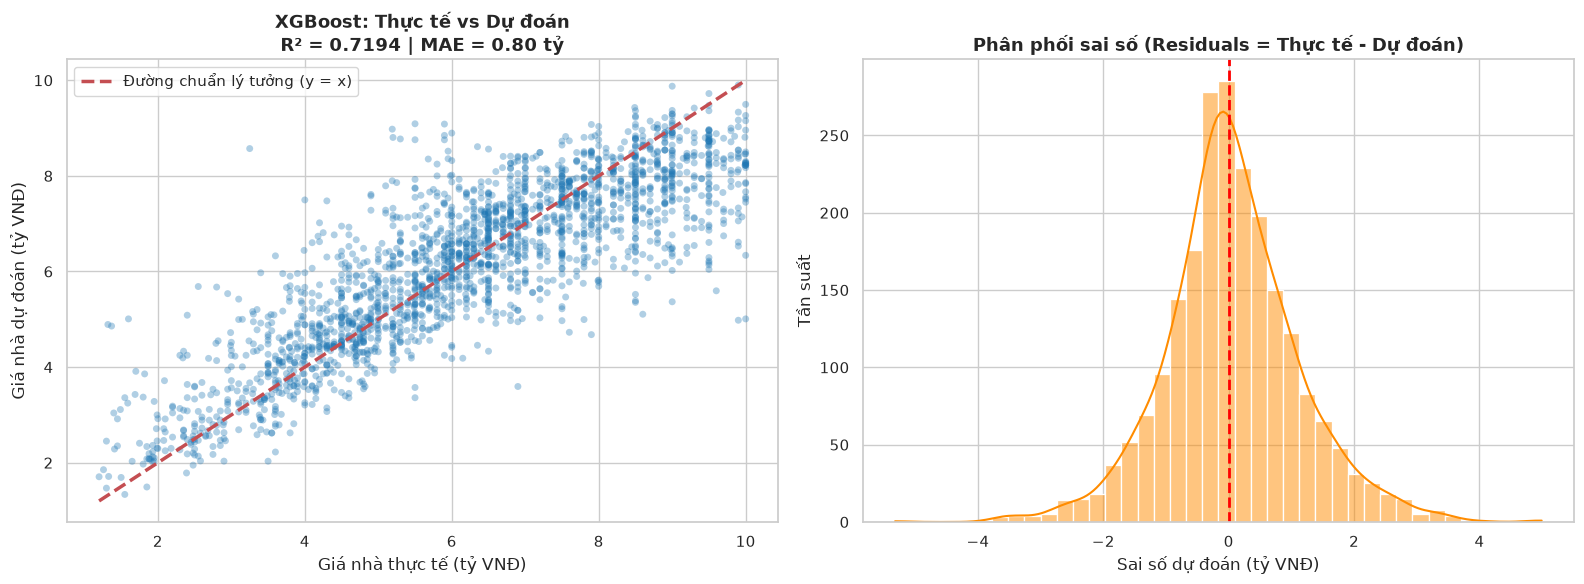

In [9]:
# 9. TRỰC QUAN HÓA KẾT QUẢ DỰ BÁO CỦA MÔ HÌNH TỐT NHẤT

y_best_pred_orig = np.expm1(best_model.predict(X_test))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị dự đoán vs thực tế
axes[0].scatter(y_test_orig, y_best_pred_orig, alpha=0.35, color='#1f77b4', edgecolors='none', s=25)
min_val = min(y_test_orig.min(), y_best_pred_orig.min())
max_val = max(y_test_orig.max(), y_best_pred_orig.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.5, label='Đường chuẩn lý tưởng (y = x)')
axes[0].set_xlabel('Giá nhà thực tế (tỷ VNĐ)', fontsize=12)
axes[0].set_ylabel('Giá nhà dự đoán (tỷ VNĐ)', fontsize=12)
axes[0].set_title(f'{best_model_name}: Thực tế vs Dự đoán\nR² = {best_r2:.4f} | MAE = {best_mae:.2f} tỷ', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper left')

#Đồ thị phân phối sai số
residuals = y_test_orig - y_best_pred_orig
sns.histplot(residuals, kde=True, ax=axes[1], color='darkorange', bins=40)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Sai số dự đoán (tỷ VNĐ)', fontsize=12)
axes[1].set_ylabel('Tần suất', fontsize=12)
axes[1].set_title('Phân phối sai số (Residuals = Thực tế - Dự đoán)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
# 10. lưu mô hình kèm các thông số đặc trưng
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

save_payload = {
    'model': best_model,
    'model_name': best_model_name,
    'features': NUM_COLS + CAT_COLS,
    'num_cols': NUM_COLS,
    'cat_cols': CAT_COLS,
    'district_median_areas': district_median_areas,
    'r2_score': best_r2,
    'mae': best_mae,
    'rmse': best_rmse
}

joblib.dump(save_payload, MODEL_SAVE_PATH)
print(f"Đã lưu thành công mô hình tối ưu vào: {MODEL_SAVE_PATH}")
print(f"- Mô hình: {best_model_name}")
print(f"- R² Score: {best_r2:.4f}")
print(f"- MAE: {best_mae:.2f} tỷ VNĐ")
print(f"- RMSE: {best_rmse:.2f} tỷ VNĐ")

Đã lưu thành công mô hình tối ưu vào: d:\05. CODE\2351050178_HuynhNgocTien\RealEstateTrading\ml\models\best_model.pkl
- Mô hình: XGBoost
- R² Score: 0.7194
- MAE: 0.80 tỷ VNĐ
- RMSE: 1.07 tỷ VNĐ
